# Assignment 5: Routing and Driver Matching in a 100-Node City Using NetworkX

**Model:** Barabási-Albert (BA) graph — `nx.barabasi_albert_graph(100, 3)`  
**Matching Strategy:** Greedy sequential (Rider 0 first, then Rider 1, etc.)  
**Tiebreaker:** Smallest driver node ID

---
## Imports and Class Setup
Imports existing classes from previous assignments (User, Rider, Driver, Ride, Car, Location).

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Existing classes from previous assignments
from user import User
from rider import Rider
from driver import Driver
from ride import Ride
from car import Car, SelfDrivenCar, HumanDrivenCar
from location import Location

# Reproducible results (seed for debugging)
random.seed(42)

---
## Part 1 — Existing Classes

This assignment builds on the OOP class hierarchy from previous assignments:  
- **User** → parent class (name, user_id, ratings)  
- **Rider** → inherits from User (current_location, preference, billing_info)  
- **Driver** → inherits from User (current_location, car, availability)  
- **Ride** → represents a single ride event (rider, driver, distance, path)  
- **Car** → with subclasses HumanDrivenCar and SelfDrivenCar  
- **Location** → wraps an integer node ID (0–99)

Each rider and driver stores their location as a `Location` object containing a single integer node ID.

---
## Part 2 — Build the City Graph

### Graph Model Choice: Barabási-Albert (BA)

The BA model uses **preferential attachment** — new nodes are more likely to connect to nodes
that already have many connections. This produces a realistic city-like topology where some
intersections are major hubs (like downtown crossroads) while most are low-traffic side streets.

**Parameters:** `n=100` nodes, `m=3` edges per new node.  
**Connectivity:** BA graphs with `m >= 2` are virtually always connected, but the generator
loops until a connected graph is confirmed.

In [2]:
def create_map_network(n=100, m=3):
    """Creates a connected Barabási-Albert graph with random edge weights.
    
    Loops until a connected graph is generated (required by assignment).
    Each edge gets a random weight between 1-10 representing travel cost
    (traffic, distance, road conditions, etc.).
    """
    while True:
        city_map = nx.barabasi_albert_graph(n, m)
        if nx.is_connected(city_map):
            break

    # Assign random edge weights for Part 5
    for u, v in city_map.edges():
        city_map[u][v]['weight'] = random.randint(1, 10)

    return city_map

city_map = create_map_network()

print(f"Nodes: {city_map.number_of_nodes()}")
print(f"Edges: {city_map.number_of_edges()}")
print(f"Connected: {nx.is_connected(city_map)}")

Nodes: 100
Edges: 291
Connected: True


### City Map Visualization

C:\Users\terry\AppData\Local\Temp\ipykernel_17496\3051556751.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


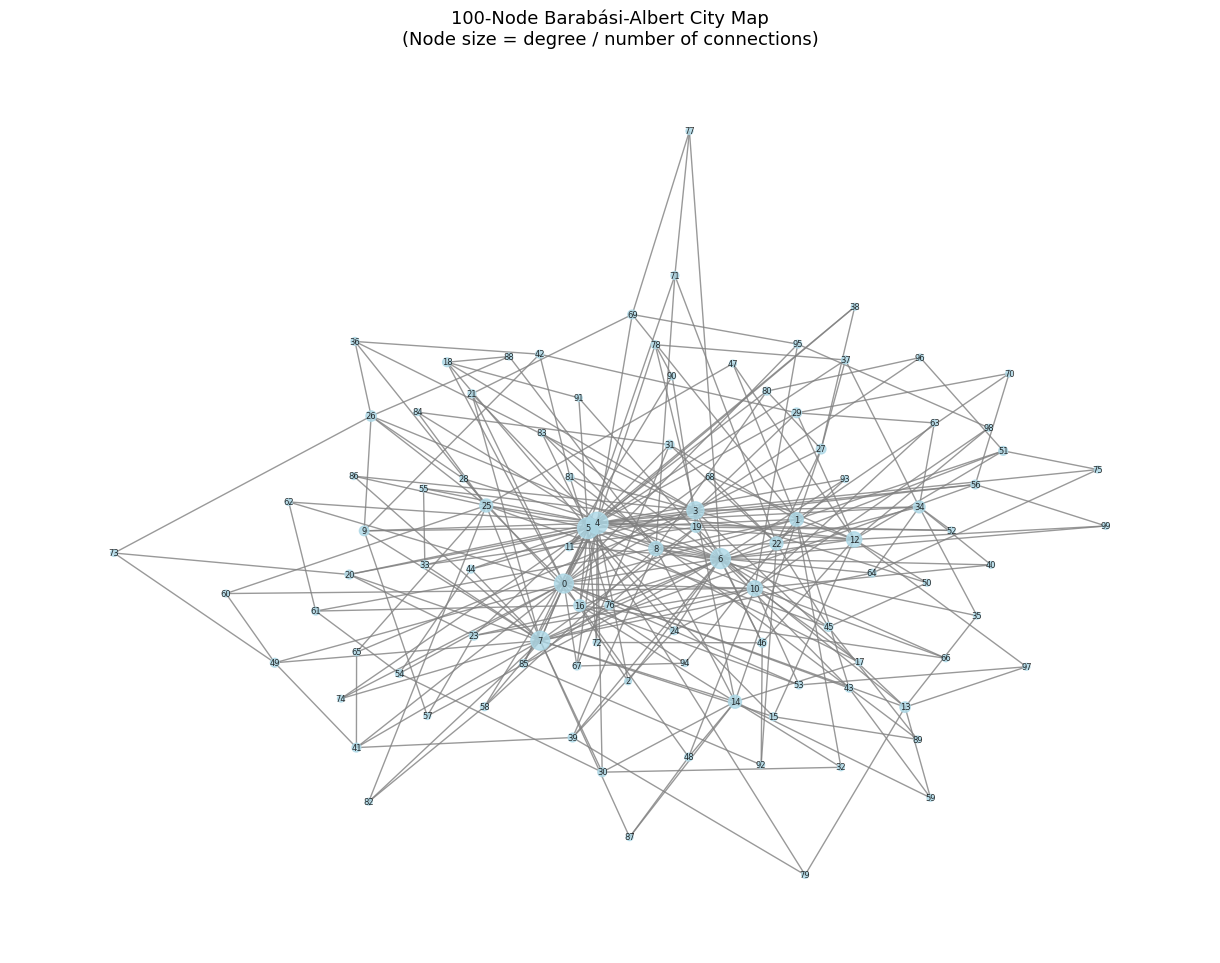

In [3]:
# Layout computed once, reused across all visualizations for consistency
pos = nx.spring_layout(city_map, seed=42)

plt.figure(figsize=(12, 9))

# Size nodes by degree (number of connections) to show hub structure
node_degrees = [city_map.degree(n) * 8 for n in city_map.nodes()]

nx.draw(city_map, pos,
        node_size=node_degrees,
        node_color='lightblue',
        edge_color='gray',
        alpha=0.8,
        with_labels=True,
        font_size=6)

plt.title("100-Node Barabási-Albert City Map\n(Node size = degree / number of connections)",
          fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 3 — Assign Riders and Drivers

- **10 Riders**, each assigned to a random node (0–99)
- **50 Drivers**, each assigned to a random node (0–99)
- Multiple riders/drivers may share the same node (allowed by assignment)

In [ ]:
rider_names = ["Alice", "Marcus", "Priya", "Jordan", "Taylor",
               "Blake", "Cameron", "Dakota", "Ellis", "Larry"]

driver_names = ["Carlos", "Yuki", "Rachel", "Austin", "Morgan",
                "Zach", "Sofia", "Liam", "Emma", "Noah",
                "Olivia", "Ethan", "Ava", "Mason", "Isabella",
                "Lucas", "Mia", "Oliver", "Charlotte", "Elijah",
                "Amelia", "James", "Harper", "Benjamin", "Evelyn",
                "William", "Abigail", "Henry", "Emily", "Alexander",
                "Elizabeth", "Michael", "Mila", "Daniel", "Ella",
                "Matthew", "Avery", "Jackson", "Nadia", "David",
                "Camila", "Joseph", "Aria", "Carter", "Scarlett",
                "Owen", "Victoria", "Wyatt", "Madison", "John"]

all_nodes = list(city_map.nodes())

# --- Create 10 Riders ---
riders = []
for i in range(10):
    node = random.choice(all_nodes)
    loc = Location(node)
    rider = Rider(name=rider_names[i], user_id=f"R{i}", current_location=loc)
    riders.append(rider)

# --- Create 50 Drivers ---
car_options = [
    (HumanDrivenCar, "Toyota", "Camry"),
    (HumanDrivenCar, "Honda", "Accord"),
    (SelfDrivenCar, "Tesla", "Model 3"),
    (HumanDrivenCar, "BMW", "X5"),
    (SelfDrivenCar, "Tesla", "Model Y"),
]

drivers = []
for i in range(50):
    node = random.choice(all_nodes)
    loc = Location(node)
    car_class, make, model = car_options[i % len(car_options)]
    car = car_class(2025, make, model, f"P{i:03d}")
    driver = Driver(name=driver_names[i], user_id=f"D{i}",
                    car=car, current_location=loc)
    drivers.append(driver)

### Rider and Driver Locations (Part 6, Section 1)

In [ ]:
print("--- Rider Locations ---")
for i, rider in enumerate(riders):
    print(f"Rider {i} ({rider.get_name()}) → Node {rider.get_current_location().get_node()}")

print("\n--- Driver Locations ---")
for i, driver in enumerate(drivers):
    print(f"Driver {i} ({driver.get_name()}) → Node {driver.get_current_location().get_node()}")

### Rider and Driver Placement Visualization

In [ ]:
plt.figure(figsize=(12, 9))

# Draw base graph
nx.draw_networkx_edges(city_map, pos, edge_color='lightgray', alpha=0.5)
nx.draw_networkx_nodes(city_map, pos, node_size=20, node_color='lightgray', alpha=0.5)

# Highlight rider nodes (red)
rider_node_ids = [r.get_current_location().get_node() for r in riders]
nx.draw_networkx_nodes(city_map, pos,
                       nodelist=rider_node_ids,
                       node_size=200, node_color='red',
                       label='Riders')

# Highlight driver nodes (blue)
driver_node_ids = [d.get_current_location().get_node() for d in drivers]
nx.draw_networkx_nodes(city_map, pos,
                       nodelist=driver_node_ids,
                       node_size=80, node_color='dodgerblue',
                       label='Drivers')

# Label rider nodes
rider_labels = {r.get_current_location().get_node(): f"R{i}" for i, r in enumerate(riders)}
nx.draw_networkx_labels(city_map, pos, labels=rider_labels, font_size=8, font_color='darkred')

plt.legend(scatterpoints=1, fontsize=11)
plt.title("Rider and Driver Placement on City Map", fontsize=13)
plt.tight_layout()
plt.show()

---
## Parts 4 & 5 — Greedy Sequential Matching Algorithm

A single `greedy_match` function handles both unweighted and weighted matching.  
The only difference is the `weight` parameter passed to `nx.shortest_path_length`:

- **Unweighted** (`weight=None`): counts hops — every edge costs 1  
- **Weighted** (`weight='weight'`): sums edge weights — uses the random 1–10 values

### How the algorithm works:

```
For each rider (in order: Rider 0, Rider 1, ... Rider 9):
    For each available driver:
        Compute shortest path distance (rider node → driver node)
    Pick the driver with the smallest distance
    If tie → pick driver with smallest node ID
    Create a Ride object for this match
    Remove that driver from the available pool
```

This is "greedy" because each rider takes the best available option at their turn,
without considering how it affects later riders.

In [ ]:
def greedy_match(graph, riders, drivers, weight=None):
    """Greedy sequential matching: each rider is matched to the
    closest available driver by shortest-path distance.

    Parameters:
        graph   — NetworkX graph (the city map)
        riders  — list of Rider objects (matched in order)
        drivers — list of Driver objects (pool of available drivers)
        weight  — None for unweighted (hops), 'weight' for weighted

    Returns:
        list of result dicts, one per rider
    """

    # Track available drivers by their index in the drivers list
    available = set(range(len(drivers)))
    results = []

    for rider_idx, rider in enumerate(riders):
        rider_node = rider.get_current_location().get_node()

        best_driver_idx = None
        best_distance = float('inf')
        best_driver_node = float('inf')  # Tiebreaker: smallest node ID

        # Compare rider against every available driver
        for d_idx in available:
            driver_node = drivers[d_idx].get_current_location().get_node()

            distance = nx.shortest_path_length(
                graph, rider_node, driver_node, weight=weight)

            # Select minimum distance; break ties by smallest node ID
            if (distance < best_distance or
                (distance == best_distance and driver_node < best_driver_node)):
                best_distance = distance
                best_driver_idx = d_idx
                best_driver_node = driver_node

        # Lock in the match
        available.remove(best_driver_idx)
        matched_driver = drivers[best_driver_idx]

        # Compute the actual path (for display and Ride object)
        path = nx.shortest_path(
            graph, rider_node,
            matched_driver.get_current_location().get_node(),
            weight=weight)

        # Create Ride object and store distance/path
        driver_loc = matched_driver.get_current_location()
        ride = Ride(rider, matched_driver, driver_loc)
        ride._distance = best_distance
        ride._path = path

        # Mark driver as unavailable
        matched_driver.go_offline()

        results.append({
            "rider_idx": rider_idx,
            "rider": rider,
            "driver_idx": best_driver_idx,
            "driver": matched_driver,
            "distance": best_distance,
            "path": path,
            "ride": ride
        })

    return results

---
## Part 4 — Unweighted Matching Results (Hop Count)

In [ ]:
unweighted_results = greedy_match(city_map, riders, drivers, weight=None)

print("========== UNWEIGHTED MATCHING (Hop Count) ==========")
for r in unweighted_results:
    print(f"\nRider {r['rider_idx']} ({r['rider'].get_name()}) "
          f"matched with Driver {r['driver_idx']} ({r['driver'].get_name()})")
    print(f"  Distance (hops): {r['distance']}")
    print(f"  Path: {r['path']}")

### Unweighted Match Visualization
Each colored line shows the shortest hop-count path from a rider (red) to their matched driver (blue).

In [ ]:
def visualize_matches(graph, pos, results, title):
    """Draws the city graph with match paths highlighted."""

    plt.figure(figsize=(12, 9))

    # Base graph
    nx.draw_networkx_edges(graph, pos, edge_color='lightgray', alpha=0.3)
    nx.draw_networkx_nodes(graph, pos, node_size=15, node_color='lightgray', alpha=0.4)

    # Color palette for match paths
    colors = plt.cm.tab10.colors

    for r in results:
        color = colors[r['rider_idx'] % len(colors)]
        path = r['path']

        # Draw path edges
        path_edges = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(graph, pos,
                               edgelist=path_edges,
                               edge_color=[color],
                               width=2.5, alpha=0.8)

        # Rider node (red square)
        rider_node = r['rider'].get_current_location().get_node()
        nx.draw_networkx_nodes(graph, pos,
                               nodelist=[rider_node],
                               node_size=180, node_color='red',
                               node_shape='s')

        # Driver node (blue circle)
        driver_node = r['driver'].get_current_location().get_node()
        nx.draw_networkx_nodes(graph, pos,
                               nodelist=[driver_node],
                               node_size=120, node_color='dodgerblue')

    # Rider labels
    rider_labels = {r['rider'].get_current_location().get_node(): f"R{r['rider_idx']}"
                    for r in results}
    nx.draw_networkx_labels(graph, pos, labels=rider_labels,
                            font_size=8, font_color='darkred', font_weight='bold')

    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


visualize_matches(city_map, pos, unweighted_results,
                  "Unweighted Matching — Shortest Hop Paths")

---
## Part 5 — Weighted Matching Results (Edge Weights)

In [ ]:
# Reset driver availability for the separate weighted run
for driver in drivers:
    driver.go_online()

weighted_results = greedy_match(city_map, riders, drivers, weight='weight')

print("========== WEIGHTED MATCHING (Edge Weights) ==========")
for r in weighted_results:
    print(f"\nRider {r['rider_idx']} ({r['rider'].get_name()}) "
          f"matched with Driver {r['driver_idx']} ({r['driver'].get_name()})")
    print(f"  Distance (weighted): {r['distance']}")
    print(f"  Path: {r['path']}")

In [ ]:
visualize_matches(city_map, pos, weighted_results,
                  "Weighted Matching — Shortest Weighted Paths")

---
## Part 6 — Comparison Summary

In [ ]:
print("========== COMPARISON: UNWEIGHTED vs. WEIGHTED ==========")
print(f"{'Rider':<12} {'Unweighted Driver':<22} {'Weighted Driver':<22} {'Changed?'}")
print("-" * 70)

changed = 0
changed_riders = []

for uw, w in zip(unweighted_results, weighted_results):
    name = uw['rider'].get_name()
    uw_driver = f"D{uw['driver_idx']} ({uw['driver'].get_name()})"
    w_driver = f"D{w['driver_idx']} ({w['driver'].get_name()})"
    is_different = uw['driver_idx'] != w['driver_idx']

    if is_different:
        changed += 1
        changed_riders.append(name)

    marker = "  ← CHANGED" if is_different else ""
    print(f"R{uw['rider_idx']} {name:<8} {uw_driver:<22} {w_driver:<22}{marker}")

print(f"\n{changed} out of {len(riders)} riders were matched to a different driver.")
if changed_riders:
    print(f"Riders who changed: {', '.join(changed_riders)}")